In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Number of observations
T = 1000

# Time
t = np.arange(T)

# Underlying signal
signal = np.sin(2 * np.pi * t / 50)

# Time-varying noise level
sigma = np.where(
    (t >= 300) & (t < 600),
    1.0,      # High-noise region
    0.2       # Low-noise region
)

# Gaussian noise
noise = np.random.normal(
    loc=0,
    scale=sigma
)

# Observed time series
y = signal + noise

print("y shape:", y.shape)
print("sigma shape:", sigma.shape)

y shape: (1000,)
sigma shape: (1000,)


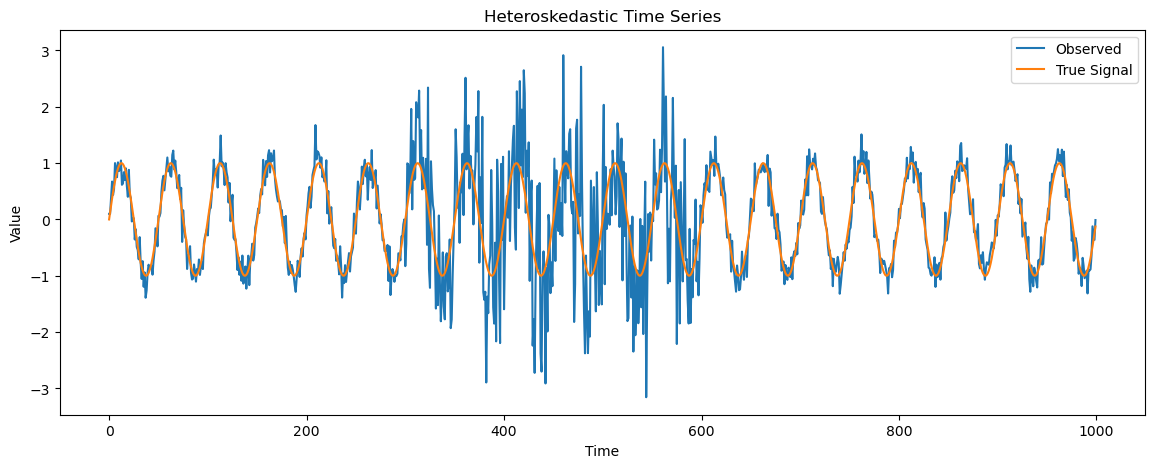

In [2]:
plt.figure(figsize=(14, 5))

plt.plot(t, y, label="Observed")
plt.plot(t, signal, label="True Signal")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Heteroskedastic Time Series")

plt.legend()
plt.show()

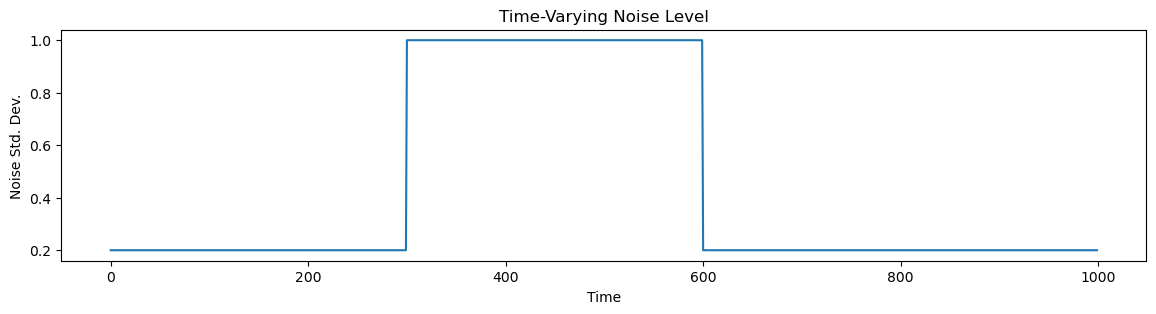

In [3]:
plt.figure(figsize=(14, 3))

plt.plot(t, sigma)

plt.xlabel("Time")
plt.ylabel("Noise Std. Dev.")
plt.title("Time-Varying Noise Level")

plt.show()

In [4]:
# Chronological split
train_end = 700
cal_end = 850

y_train = y[:train_end]
y_cal   = y[train_end:cal_end]
y_test  = y[cal_end:]

print("Train:", y_train.shape)
print("Calibration:", y_cal.shape)
print("Test:", y_test.shape)

Train: (700,)
Calibration: (150,)
Test: (150,)


In [5]:
def create_sequences(data, seq_length=5):
    X = []
    y_target = []

    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y_target.append(data[i + seq_length])

    return np.array(X), np.array(y_target)

In [6]:
seq_length = 5

X_train, y_train_target = create_sequences(
    y_train,
    seq_length
)

X_cal, y_cal_target = create_sequences(
    y_cal,
    seq_length
)

X_test, y_test_target = create_sequences(
    y_test,
    seq_length
)

In [7]:
X_train = X_train.reshape(-1, seq_length, 1)
X_cal   = X_cal.reshape(-1, seq_length, 1)
X_test  = X_test.reshape(-1, seq_length, 1)

In [8]:
print("X_train:", X_train.shape)
print("y_train:", y_train_target.shape)

print("X_cal:", X_cal.shape)
print("y_cal:", y_cal_target.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test_target.shape)

X_train: (695, 5, 1)
y_train: (695,)
X_cal: (145, 5, 1)
y_cal: (145,)
X_test: (145, 5, 1)
y_test: (145,)


In [9]:
import torch
import torch.nn as nn

# Reproducibility for PyTorch
torch.manual_seed(42)

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.as_tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.as_tensor(
    y_train_target,
    dtype=torch.float32
)

X_cal_tensor = torch.as_tensor(
    X_cal,
    dtype=torch.float32
)

y_cal_tensor = torch.as_tensor(
    y_cal_target,
    dtype=torch.float32
)

X_test_tensor = torch.as_tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.as_tensor(
    y_test_target,
    dtype=torch.float32
)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

print("X_cal:", X_cal_tensor.shape)
print("y_cal:", y_cal_tensor.shape)

print("X_test:", X_test_tensor.shape)
print("y_test:", y_test_tensor.shape)

X_train: torch.Size([695, 5, 1])
y_train: torch.Size([695])
X_cal: torch.Size([145, 5, 1])
y_cal: torch.Size([145])
X_test: torch.Size([145, 5, 1])
y_test: torch.Size([145])


In [10]:
class QuantileLSTM(nn.Module):

    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            2
        )

    def forward(self, x):

        # LSTM processes all 5 timestamps
        output, (h_n, c_n) = self.lstm(x)

        # Take hidden representation from the last timestamp
        last_hidden = output[:, -1, :]

        # Predict lower and upper quantiles
        quantiles = self.fc(last_hidden)

        return quantiles

In [11]:
model = QuantileLSTM(
    input_size=1,
    hidden_size=32
)

print(model)

QuantileLSTM(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=2, bias=True)
)


In [12]:
def pinball_loss(predictions, targets, quantiles):

    losses = []

    for i, q in enumerate(quantiles):

        errors = targets - predictions[:, i]

        loss = torch.maximum(
            q * errors,
            (q - 1) * errors
        )

        losses.append(loss.unsqueeze(1))

    losses = torch.cat(losses, dim=1)

    return losses.mean()

In [13]:
quantiles = [0.1, 0.9]

In [14]:
x_batch = X_train_tensor[:10]
y_batch = y_train_tensor[:10]

predictions = model(x_batch)

loss = pinball_loss(
    predictions,
    y_batch,
    quantiles
)

print("Predictions shape:", predictions.shape)
print("Pinball Loss:", loss.item())

Predictions shape: torch.Size([10, 2])
Pinball Loss: 0.3852974772453308


In [15]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 40

for epoch in range(num_epochs):

    # Training mode
    model.train()

    # Forward pass
    predictions = model(X_train_tensor)

    # Calculate Pinball Loss
    loss = pinball_loss(
        predictions,
        y_train_tensor,
        quantiles
    )

    # Clear old gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update model parameters
    optimizer.step()

    # Validation
    model.eval()

    with torch.no_grad():

        val_predictions = model(X_cal_tensor)

        val_loss = pinball_loss(
            val_predictions,
            y_cal_tensor,
            quantiles
        )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {loss.item():.4f} | "
        f"Val Loss: {val_loss.item():.4f}"
    )

Epoch 1/40 | Train Loss: 0.4163 | Val Loss: 0.3470
Epoch 2/40 | Train Loss: 0.4131 | Val Loss: 0.3437
Epoch 3/40 | Train Loss: 0.4099 | Val Loss: 0.3404
Epoch 4/40 | Train Loss: 0.4067 | Val Loss: 0.3371
Epoch 5/40 | Train Loss: 0.4035 | Val Loss: 0.3338
Epoch 6/40 | Train Loss: 0.4002 | Val Loss: 0.3304
Epoch 7/40 | Train Loss: 0.3970 | Val Loss: 0.3270
Epoch 8/40 | Train Loss: 0.3937 | Val Loss: 0.3235
Epoch 9/40 | Train Loss: 0.3904 | Val Loss: 0.3201
Epoch 10/40 | Train Loss: 0.3871 | Val Loss: 0.3165
Epoch 11/40 | Train Loss: 0.3838 | Val Loss: 0.3129
Epoch 12/40 | Train Loss: 0.3804 | Val Loss: 0.3093
Epoch 13/40 | Train Loss: 0.3769 | Val Loss: 0.3056
Epoch 14/40 | Train Loss: 0.3734 | Val Loss: 0.3019
Epoch 15/40 | Train Loss: 0.3698 | Val Loss: 0.2982
Epoch 16/40 | Train Loss: 0.3662 | Val Loss: 0.2943
Epoch 17/40 | Train Loss: 0.3625 | Val Loss: 0.2904
Epoch 18/40 | Train Loss: 0.3587 | Val Loss: 0.2864
Epoch 19/40 | Train Loss: 0.3549 | Val Loss: 0.2822
Epoch 20/40 | Train L

Epoch 24/40 | Train Loss: 0.3345 | Val Loss: 0.2599
Epoch 25/40 | Train Loss: 0.3302 | Val Loss: 0.2550
Epoch 26/40 | Train Loss: 0.3256 | Val Loss: 0.2501
Epoch 27/40 | Train Loss: 0.3210 | Val Loss: 0.2450
Epoch 28/40 | Train Loss: 0.3162 | Val Loss: 0.2398
Epoch 29/40 | Train Loss: 0.3112 | Val Loss: 0.2345
Epoch 30/40 | Train Loss: 0.3061 | Val Loss: 0.2289
Epoch 31/40 | Train Loss: 0.3009 | Val Loss: 0.2232
Epoch 32/40 | Train Loss: 0.2955 | Val Loss: 0.2172
Epoch 33/40 | Train Loss: 0.2899 | Val Loss: 0.2112
Epoch 34/40 | Train Loss: 0.2841 | Val Loss: 0.2052
Epoch 35/40 | Train Loss: 0.2781 | Val Loss: 0.1990
Epoch 36/40 | Train Loss: 0.2719 | Val Loss: 0.1926
Epoch 37/40 | Train Loss: 0.2657 | Val Loss: 0.1858
Epoch 38/40 | Train Loss: 0.2594 | Val Loss: 0.1788
Epoch 39/40 | Train Loss: 0.2529 | Val Loss: 0.1716
Epoch 40/40 | Train Loss: 0.2464 | Val Loss: 0.1644


In [16]:
model.eval()

with torch.no_grad():
    test_quantiles = model(X_test_tensor)

test_lower_raw = test_quantiles[:, 0]
test_upper_raw = test_quantiles[:, 1]

print("Test quantile shape:", test_quantiles.shape)

print("First 10 quantile predictions:")
print(test_quantiles[:10])

Test quantile shape: torch.Size([145, 2])
First 10 quantile predictions:
tensor([[-0.2896,  0.5887],
        [-0.2828,  0.6041],
        [-0.2766,  0.6099],
        [-0.2630,  0.6234],
        [-0.2611,  0.6306],
        [-0.2512,  0.6415],
        [-0.2431,  0.6550],
        [-0.2462,  0.6547],
        [-0.2324,  0.6628],
        [-0.2211,  0.6804]])


In [17]:
crossings = test_lower_raw > test_upper_raw

print("Number of crossed intervals:", crossings.sum().item())

Number of crossed intervals: 0


In [18]:
test_actual = y_test_tensor

covered = (
    (test_actual >= test_lower_raw) &
    (test_actual <= test_upper_raw)
)

raw_coverage = covered.float().mean()

raw_width = test_upper_raw - test_lower_raw
avg_raw_width = raw_width.mean()

print("Raw interval coverage:", raw_coverage.item())
print("Coverage (%):", raw_coverage.item() * 100)
print("Average raw interval width:", avg_raw_width.item())

Raw interval coverage: 0.32413792610168457
Coverage (%): 32.41379261016846
Average raw interval width: 0.8579237461090088


In [19]:
model.eval()

with torch.no_grad():
    cal_quantiles = model(X_cal_tensor)

cal_lower = cal_quantiles[:, 0]
cal_upper = cal_quantiles[:, 1]

# CQR conformity scores
cal_scores = torch.maximum(
    cal_lower - y_cal_tensor,
    y_cal_tensor - cal_upper
)

cal_scores = torch.maximum(
    cal_scores,
    torch.zeros_like(cal_scores)
)

print("First 10 CQR scores:")
print(cal_scores[:10])

print("Number of calibration samples:", len(cal_scores))

First 10 CQR scores:
tensor([0.1570, 0.0000, 0.5341, 0.0000, 0.6195, 0.3502, 0.3058, 0.2237, 0.4152,
        0.3052])
Number of calibration samples: 145


In [20]:
alpha = 0.10

n = len(cal_scores)

k = int(np.ceil((n + 1) * (1 - alpha)))

sorted_scores = torch.sort(cal_scores).values

q_cqr = sorted_scores[k - 1]

print("Number of calibration samples:", n)
print("k:", k)
print("CQR conformal q:", q_cqr.item())

Number of calibration samples: 145
k: 132
CQR conformal q: 0.5808618068695068


In [21]:
model.eval()

with torch.no_grad():
    test_quantiles = model(X_test_tensor)

test_lower_raw = test_quantiles[:, 0]
test_upper_raw = test_quantiles[:, 1]

# Apply CQR correction
test_lower_cqr = test_lower_raw - q_cqr
test_upper_cqr = test_upper_raw + q_cqr

# Check coverage
covered_cqr = (
    (y_test_tensor >= test_lower_cqr) &
    (y_test_tensor <= test_upper_cqr)
)

cqr_coverage = covered_cqr.float().mean()

# Interval widths
cqr_width = test_upper_cqr - test_lower_cqr
avg_cqr_width = cqr_width.mean()

print("CQR Coverage:", cqr_coverage.item())
print("CQR Coverage (%):", cqr_coverage.item() * 100)
print("Average CQR interval width:", avg_cqr_width.item())

CQR Coverage: 0.8965517282485962
CQR Coverage (%): 89.65517282485962
Average CQR interval width: 2.0196473598480225


In [22]:
sigma_test = sigma[850 + 5:]

In [23]:
low_noise_mask = sigma_test == 0.2
high_noise_mask = sigma_test == 1.0

low_width = cqr_width[low_noise_mask]
high_width = cqr_width[high_noise_mask]

print("Low-noise samples:", len(low_width))
print("High-noise samples:", len(high_width))

print("Average CQR width - Low noise:",
      low_width.mean().item())

print("Average CQR width - High noise:",
      high_width.mean().item())

Low-noise samples: 145
High-noise samples: 0
Average CQR width - Low noise: 2.0196473598480225
Average CQR width - High noise: nan


In [24]:
print("sigma shape:", sigma.shape)
print("Unique sigma values:", np.unique(sigma))
print("First 20 sigma:", sigma[:20])
print("Last 20 sigma:", sigma[-20:])

sigma shape: (1000,)
Unique sigma values: [0.2 1. ]
First 20 sigma: [0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2
 0.2 0.2]
Last 20 sigma: [0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2
 0.2 0.2]


In [25]:
print("Test sigma unique values:")
print(np.unique(sigma[850:1000], return_counts=True))

Test sigma unique values:
(array([0.2]), array([150]))


In [26]:
print("High-noise indices:")
print(np.where(sigma == 1.0)[0][:10])

print("High-noise start:",
      np.where(sigma == 1.0)[0].min())

print("High-noise end:",
      np.where(sigma == 1.0)[0].max())

print("Number of high-noise points:",
      np.sum(sigma == 1.0))

High-noise indices:
[300 301 302 303 304 305 306 307 308 309]
High-noise start: 300
High-noise end: 599
Number of high-noise points: 300


In [27]:
# Sequence length
seq_len = 5

# Original target indices for each split
train_target_indices = np.arange(
    seq_len,
    seq_len + len(y_train_target)
)

cal_target_indices = np.arange(
    seq_len + len(y_train_target),
    seq_len + len(y_train_target) + len(y_cal_target)
)

test_target_indices = np.arange(
    seq_len + len(y_train_target) + len(y_cal_target),
    seq_len + len(y_train_target) + len(y_cal_target) + len(y_test_target)
)

print("Train target index range:",
      train_target_indices[0],
      "to",
      train_target_indices[-1])

print("Calibration target index range:",
      cal_target_indices[0],
      "to",
      cal_target_indices[-1])

print("Test target index range:",
      test_target_indices[0],
      "to",
      test_target_indices[-1])

Train target index range: 5 to 699
Calibration target index range: 700 to 844
Test target index range: 845 to 989


In [28]:
model.eval()

with torch.no_grad():
    train_quantiles = model(X_train_tensor)

train_lower = train_quantiles[:, 0]
train_upper = train_quantiles[:, 1]

train_width = train_upper - train_lower

print("Train prediction shape:", train_quantiles.shape)
print("Train width shape:", train_width.shape)

Train prediction shape: torch.Size([695, 2])
Train width shape: torch.Size([695])


In [29]:
high_noise_train_mask = (
    (train_target_indices >= 300) &
    (train_target_indices <= 599)
)

low_noise_train_mask = (
    (train_target_indices < 300) |
    (train_target_indices > 599)
)

high_width = train_width[high_noise_train_mask]
low_width = train_width[low_noise_train_mask]

print("High-noise samples:", len(high_width))
print("Low-noise samples:", len(low_width))

print(
    "Average raw interval width - High noise:",
    high_width.mean().item()
)

print(
    "Average raw interval width - Low noise:",
    low_width.mean().item()
)

High-noise samples: 300
Low-noise samples: 395
Average raw interval width - High noise: 0.8441771268844604
Average raw interval width - Low noise: 0.8565059900283813


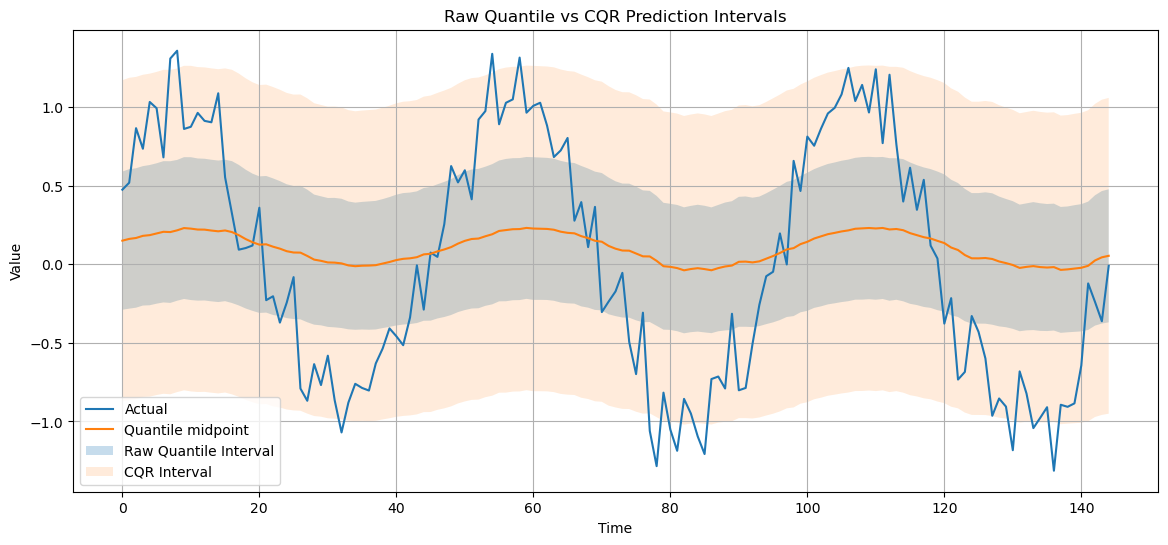

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Convert tensors to NumPy
actuals_np = y_test_tensor.detach().cpu().numpy()
predictions_np = (
    (test_lower_raw + test_upper_raw) / 2
).detach().cpu().numpy()

raw_lower_np = test_lower_raw.detach().cpu().numpy()
raw_upper_np = test_upper_raw.detach().cpu().numpy()

cqr_lower_np = test_lower_cqr.detach().cpu().numpy()
cqr_upper_np = test_upper_cqr.detach().cpu().numpy()

time = np.arange(len(actuals_np))

plt.figure(figsize=(14, 6))

plt.plot(
    time,
    actuals_np,
    label="Actual"
)

plt.plot(
    time,
    predictions_np,
    label="Quantile midpoint"
)

plt.fill_between(
    time,
    raw_lower_np,
    raw_upper_np,
    alpha=0.25,
    label="Raw Quantile Interval"
)

plt.fill_between(
    time,
    cqr_lower_np,
    cqr_upper_np,
    alpha=0.15,
    label="CQR Interval"
)

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Raw Quantile vs CQR Prediction Intervals")
plt.legend()
plt.grid(True)
plt.show()

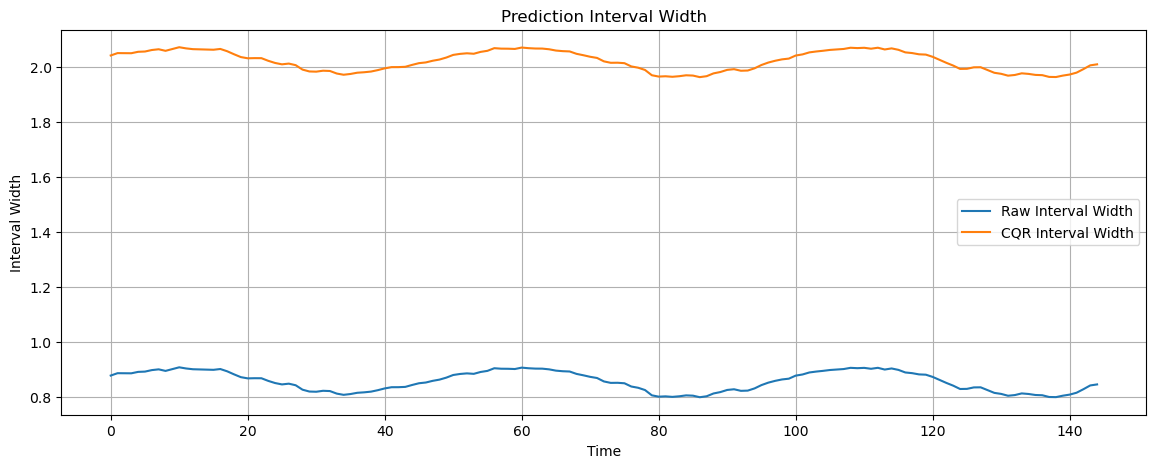

In [31]:
plt.figure(figsize=(14, 5))

plt.plot(
    time,
    raw_upper_np - raw_lower_np,
    label="Raw Interval Width"
)

plt.plot(
    time,
    cqr_upper_np - cqr_lower_np,
    label="CQR Interval Width"
)

plt.xlabel("Time")
plt.ylabel("Interval Width")
plt.title("Prediction Interval Width")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# Absolute prediction error
prediction_error = np.abs(
    actuals_np - predictions_np
)

# Raw interval width
raw_width = raw_upper_np - raw_lower_np

# Correlation between interval width and prediction error
correlation = np.corrcoef(
    raw_width,
    prediction_error
)[0, 1]

print("Correlation between interval width and absolute error:",
      correlation)

Correlation between interval width and absolute error: -0.19085487247244692
